# Hybrid Fraud Detection Model

This notebook trains a supervised XGBoost fraud detection model
and integrates an anomaly detection signal generated using Isolation Forest.

Architecture:

Transaction Features
        │
        ├── XGBoost Model → fraud probability
        │
        ├── Isolation Forest → anomaly score
        │
        ▼
Fraud Decision Engine

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve

import xgboost as xgb

In [2]:
#Load Dataset
df = pd.read_csv("../data/processed/fraud_features_with_anomaly_iforest.csv")

print(df.shape)
df.head()

(441762, 20)


,TransactionDT,TransactionAmt,customer_id,card1,card2,ProductCD,isFraud,txn_count_1h,txn_count_24h,txn_count_7d,avg_amt_1h,avg_amt_24h,avg_amt_7d,max_amt_24h,amount_dev_24h,std_amt_24h,amount_zscore_24h,hour,is_night_txn,anomaly_score
0,1970-04-10 22:40:15,19.093,10003_555.0,10003,555.0,C,0,2.0,2.0,3.0,14.924,14.924000,23.080667,19.093,4.169000,5.895856,0.707107,22,0,0.126938
1,1970-04-11 00:40:05,19.093,10003_555.0,10003,555.0,C,0,1.0,3.0,4.0,19.093,16.313667,22.083750,19.093,2.779333,4.813947,0.577350,0,1,0.251132
2,1970-01-16 18:25:07,100.000,10004_529.0,10004,529.0,R,0,1.0,2.0,2.0,100.000,125.000000,125.000000,150.000,-25.000000,35.355339,-0.707107,18,0,0.055967
3,1970-02-13 19:58:39,107.950,10004_529.0,10004,529.0,W,0,1.0,2.0,3.0,107.950,316.450000,736.133333,524.950,-208.500000,294.863528,-0.707107,19,0,0.126137
4,1970-02-16 09:20:45,54.490,10004_529.0,10004,529.0,W,0,1.0,2.0,4.0,54.490,42.745000,179.597500,54.490,11.745000,16.609938,0.707107,9,0,0.064168


In [3]:
# Verifying "anomaly_score" column exists
print(df.columns)

Index(['TransactionDT', 'TransactionAmt', 'customer_id', 'card1', 'card2',
       'ProductCD', 'isFraud', 'txn_count_1h', 'txn_count_24h', 'txn_count_7d',
       'avg_amt_1h', 'avg_amt_24h', 'avg_amt_7d', 'max_amt_24h',
       'amount_dev_24h', 'std_amt_24h', 'amount_zscore_24h', 'hour',
       'is_night_txn', 'anomaly_score'],
      dtype='object')


In [4]:
#Recreate Derived Feature
df["velocity_risk"] = (
    df["txn_count_1h"] / (df["txn_count_24h"] + 1)
).clip(0,1)

In [5]:
#Define Model Features
features = [
    "TransactionAmt",
    "txn_count_1h",
    "txn_count_24h",
    "txn_count_7d",
    "avg_amt_1h",
    "avg_amt_24h",
    "avg_amt_7d",
    "max_amt_24h",
    "amount_zscore_24h",
    "velocity_risk",
    "is_night_txn"
]

X = df[features]
y = df["isFraud"]

In [6]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
#Handle Class Imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 26.16650011530479


In [8]:
#Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [9]:
#Model Predictions
xgb_score = model.predict_proba(X_test)[:,1]

In [10]:
#Evaluate Baseline Model
auc = roc_auc_score(y_test, xgb_score)

print("XGBoost ROC-AUC:", auc)

XGBoost ROC-AUC: 0.7675322462146961


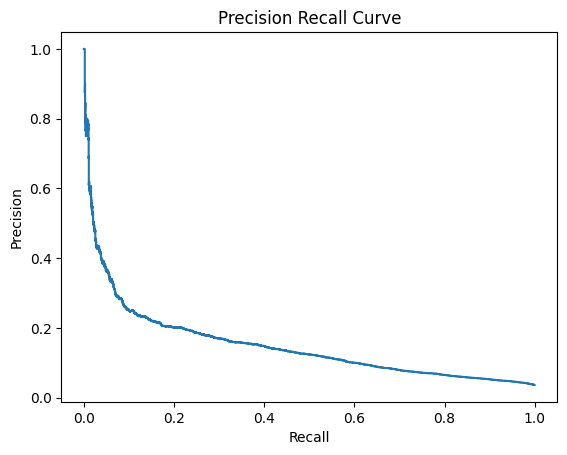

In [11]:
#Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, xgb_score)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

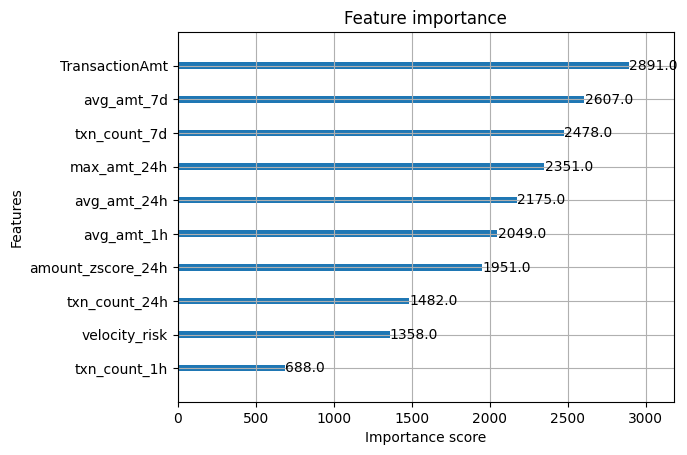

In [12]:
#Feature Importance
xgb.plot_importance(model, max_num_features=10)
plt.show()

In [13]:
#Create Results Dataset -> combine predictions + anomaly score
results = X_test.copy()

results["xgb_score"] = xgb_score
results["anomaly_score"] = df.loc[X_test.index, "anomaly_score"]
results["actual_fraud"] = y_test.values

results.head()

,TransactionAmt,txn_count_1h,txn_count_24h,txn_count_7d,avg_amt_1h,avg_amt_24h,avg_amt_7d,max_amt_24h,amount_zscore_24h,velocity_risk,is_night_txn,xgb_score,anomaly_score,actual_fraud
65040,129.950,3.0,33.0,278.0,88.966667,96.086970,112.063273,624.200,0.320448,0.088235,1,0.205671,0.239644,0
35810,20.657,1.0,13.0,49.0,20.657000,35.162000,34.965857,183.149,-0.317511,0.071429,0,0.752550,0.037411,1
177954,54.500,1.0,2.0,19.0,54.500000,41.750000,64.857895,54.500,0.707107,0.333333,0,0.334405,0.048083,0
90037,57.950,1.0,6.0,43.0,57.950000,65.550000,82.890000,150.000,-0.178345,0.142857,1,0.097315,0.136148,0
290345,48.950,1.0,6.0,14.0,48.950000,75.633333,93.675000,171.000,-0.532433,0.142857,0,0.140895,0.016482,0


In [14]:
#Fraud Decision Engine
def fraud_decision(row):

    if row["xgb_score"] > 0.7:
        return "BLOCK"

    elif row["anomaly_score"] > 0.8:
        return "INVESTIGATE"

    else:
        return "APPROVE"


results["decision"] = results.apply(fraud_decision, axis=1)

In [15]:
#Decision Distribution
results["decision"].value_counts()

decision
APPROVE        81275
BLOCK           6883
INVESTIGATE      195
Name: count, dtype: int64

In [16]:
#Save Results
results.to_csv("../data/processed/fraud_predictions.csv", index=False)

# SHAP fraud explanations

In [17]:
import shap

c:\Users\kirti\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

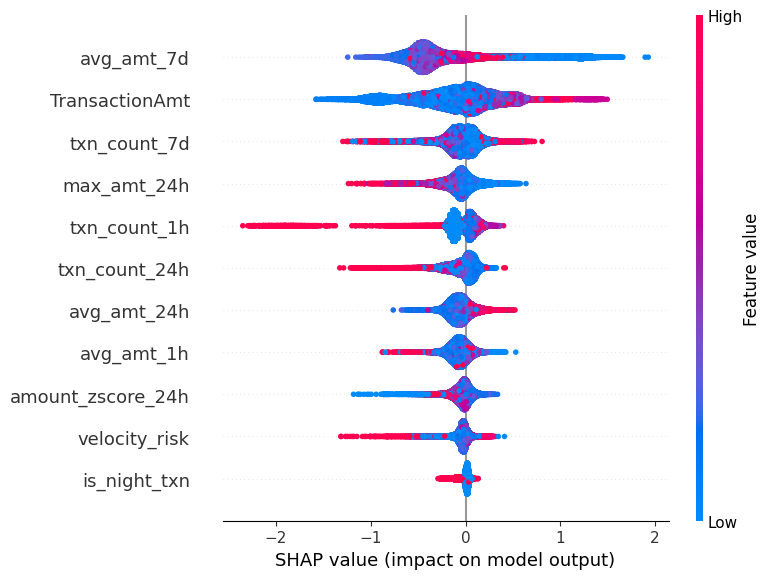

In [19]:
#Global Feature Importance
shap.summary_plot(shap_values, X_test)

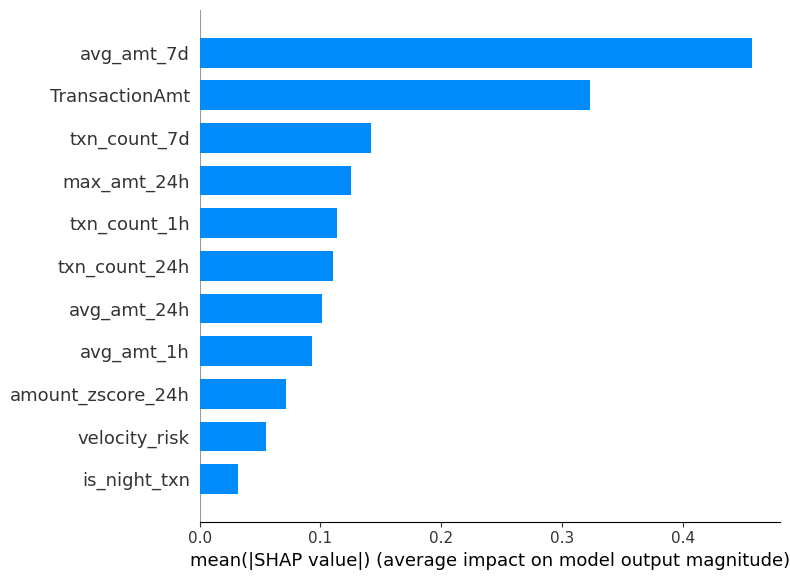

In [20]:
#SHAP Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [21]:
import shap
shap.initjs()

In [22]:
#Explain a Single Fraud Transaction
fraud_index = X_test[y_test == 1].index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[list(X_test.index).index(fraud_index)],
    X_test.loc[fraud_index]
)

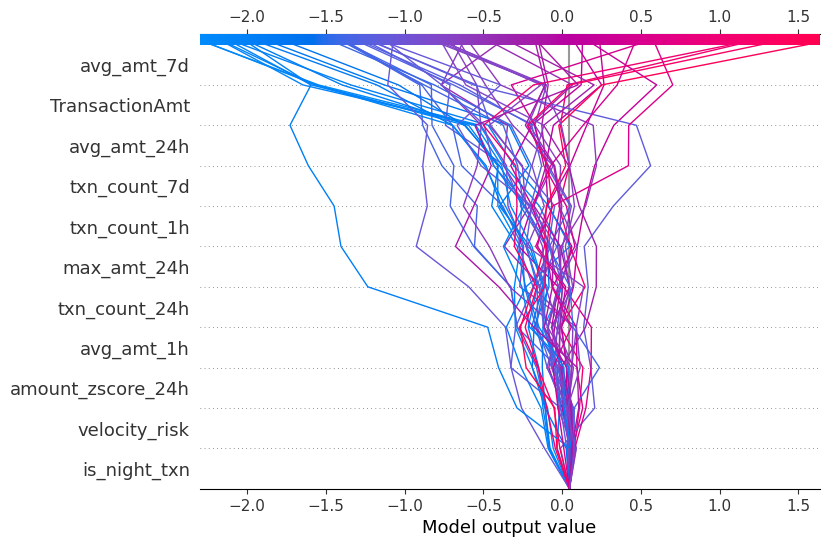

In [23]:
#SHAP Decision Plot
shap.decision_plot(
    explainer.expected_value,
    shap_values[:50],
    X_test.iloc[:50]
)

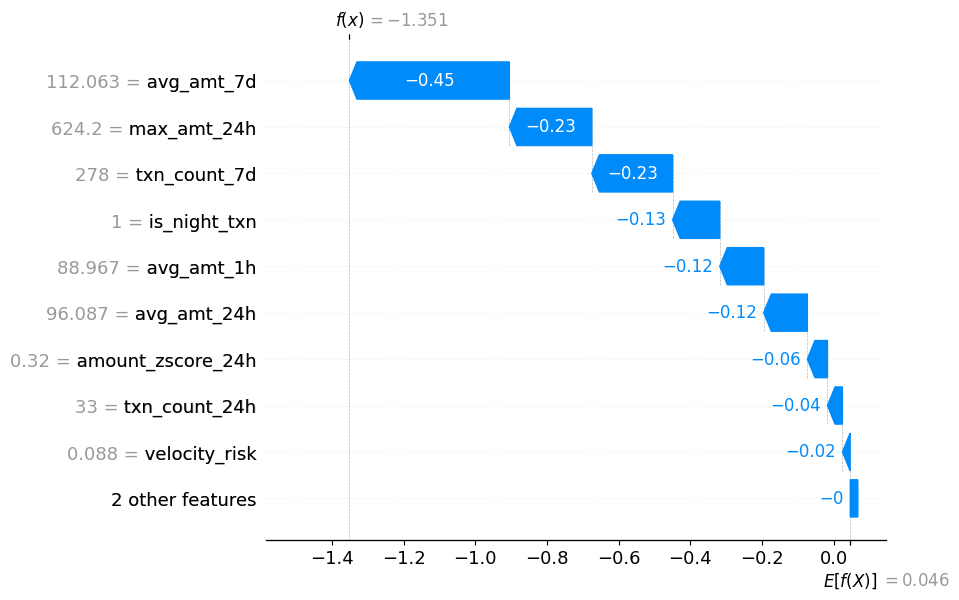

In [24]:
#Waterfall Plot
fraud_row = X_test.iloc[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=fraud_row,
        feature_names=X_test.columns
    )
)

In [25]:
import joblib

joblib.dump(model, "../models/xgb_fraud_model.pkl")

['../models/xgb_fraud_model.pkl']